# 01. Data Understanding and EDA

Notebook này tập trung vào việc **hiểu dữ liệu** và **vẽ nhiều biểu đồ quan trọng** để bạn dùng cho báo cáo và slide.

Mục tiêu:
- Xem tổng quan dữ liệu.
- Kiểm tra missing values.
- Vẽ các sơ đồ cột, sơ đồ tròn và biểu đồ phân phối.
- Rút ra insight ban đầu về churn.

In [9]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

DEFAULT_ROOT = Path(r"C:\vscode\hoctap\Customer-Churn-Analysis")

def find_project_root(start_path: Path) -> Path:
    candidates = [start_path, *start_path.parents, DEFAULT_ROOT]
    for candidate in candidates:
        if (candidate / 'src').exists() and (candidate / 'configs').exists():
            return candidate
    raise FileNotFoundError('Không tìm thấy thư mục project chứa src/ và configs/.')

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.load_data import load_dataset
from src.data.preprocess import clean_dataframe
from src.utils.config import load_project_config

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 4)

config = load_project_config(PROJECT_ROOT / 'configs' / 'config.yaml')
df_raw = load_dataset(PROJECT_ROOT / config['paths']['raw_data'])
df = clean_dataframe(df_raw)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1. Quan sát tổng quan dữ liệu

In [10]:
print('Shape:', df.shape)
print('\nColumns:')
print(df.columns.tolist())
print('\nDtypes:')
print(df.dtypes)

summary_df = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing_count': df.isna().sum(),
    'missing_ratio_%': (df.isna().mean() * 100).round(2),
    'n_unique': df.nunique()
})
summary_df

Shape: (7043, 20)

Columns:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Dtypes:
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object


,dtype,missing_count,missing_ratio_%,n_unique
gender,str,0,0.0,2
SeniorCitizen,int64,0,0.0,2
Partner,str,0,0.0,2
Dependents,str,0,0.0,2
tenure,int64,0,0.0,73
PhoneService,str,0,0.0,2
MultipleLines,str,0,0.0,3
InternetService,str,0,0.0,3
OnlineSecurity,str,0,0.0,3
OnlineBackup,str,0,0.0,3


## 2. Tỷ lệ churn tổng thể

Phần này nên có cả **sơ đồ cột** và **sơ đồ tròn** để dễ đưa vào slide.

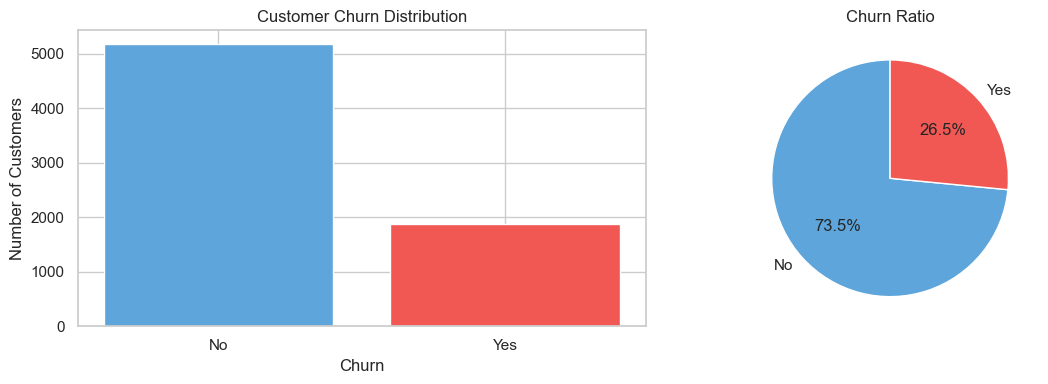

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

In [11]:
churn_counts = df['Churn'].value_counts()
churn_ratio = df['Churn'].value_counts(normalize=True).mul(100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(churn_counts.index, churn_counts.values, color=['#5DA5DA', '#F15854'])
axes[0].set_title('Customer Churn Distribution')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Number of Customers')

axes[1].pie(
    churn_counts.values,
    labels=churn_counts.index,
    autopct='%1.1f%%',
    colors=['#5DA5DA', '#F15854'],
    startangle=90,
    wedgeprops={'edgecolor': 'white'}
)
axes[1].set_title('Churn Ratio')

plt.tight_layout()
plt.show()

churn_ratio

## 3. Churn theo giới tính và nhóm khách hàng lớn tuổi

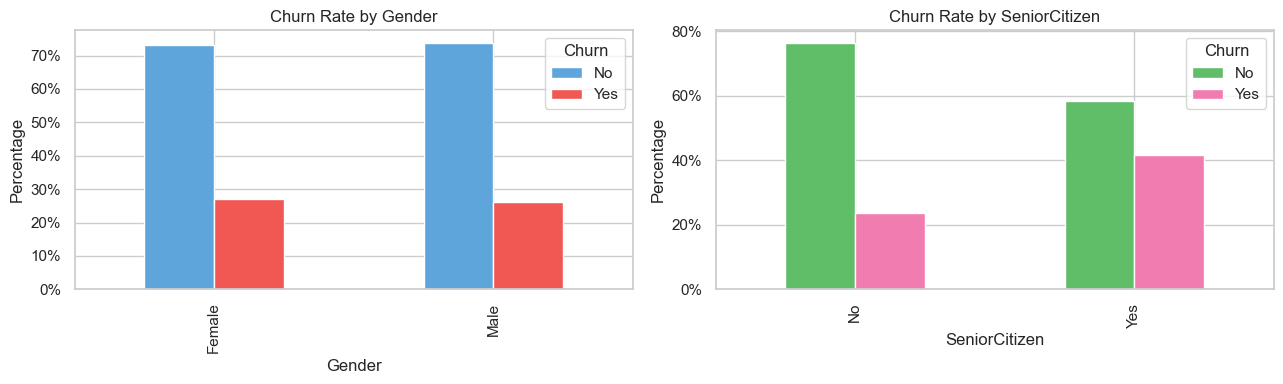

In [12]:
gender_rate = pd.crosstab(df['gender'], df['Churn'], normalize='index').mul(100)
senior_rate = pd.crosstab(df['SeniorCitizen'], df['Churn'], normalize='index').mul(100)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

gender_rate.plot(kind='bar', ax=axes[0], color=['#5DA5DA', '#F15854'])
axes[0].set_title('Churn Rate by Gender')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Percentage')
axes[0].yaxis.set_major_formatter(PercentFormatter())
axes[0].legend(title='Churn')

senior_rate.index = senior_rate.index.map({0: 'No', 1: 'Yes'})
senior_rate.plot(kind='bar', ax=axes[1], color=['#60BD68', '#F17CB0'])
axes[1].set_title('Churn Rate by SeniorCitizen')
axes[1].set_xlabel('SeniorCitizen')
axes[1].set_ylabel('Percentage')
axes[1].yaxis.set_major_formatter(PercentFormatter())
axes[1].legend(title='Churn')

plt.tight_layout()
plt.show()

## 4. Churn theo trạng thái gia đình

Hai cột `Partner` và `Dependents` thường giúp bổ sung góc nhìn về hành vi khách hàng.

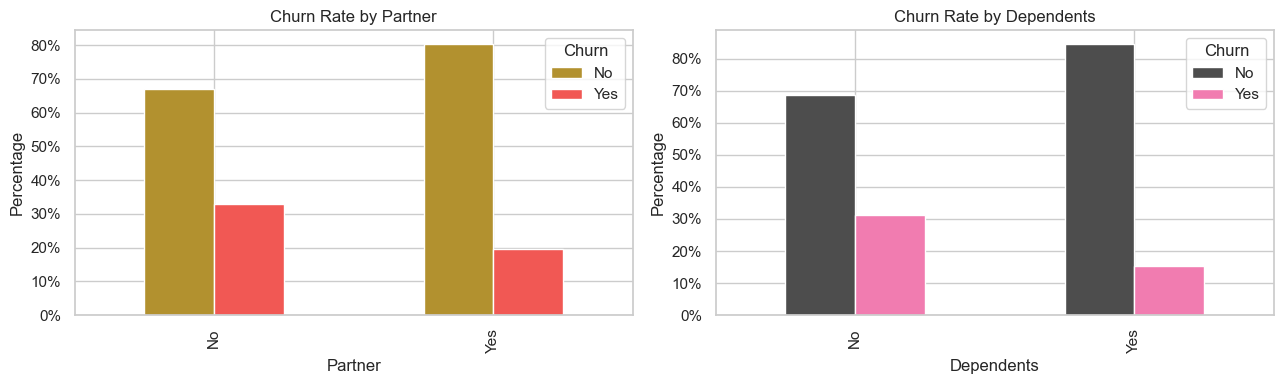

In [13]:
partner_rate = pd.crosstab(df['Partner'], df['Churn'], normalize='index').mul(100)
dependents_rate = pd.crosstab(df['Dependents'], df['Churn'], normalize='index').mul(100)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
partner_rate.plot(kind='bar', ax=axes[0], color=['#B2912F', '#F15854'])
axes[0].set_title('Churn Rate by Partner')
axes[0].set_xlabel('Partner')
axes[0].set_ylabel('Percentage')
axes[0].yaxis.set_major_formatter(PercentFormatter())
axes[0].legend(title='Churn')

dependents_rate.plot(kind='bar', ax=axes[1], color=['#4D4D4D', '#F17CB0'])
axes[1].set_title('Churn Rate by Dependents')
axes[1].set_xlabel('Dependents')
axes[1].set_ylabel('Percentage')
axes[1].yaxis.set_major_formatter(PercentFormatter())
axes[1].legend(title='Churn')

plt.tight_layout()
plt.show()

## 5. Churn theo loại hợp đồng và phương thức thanh toán

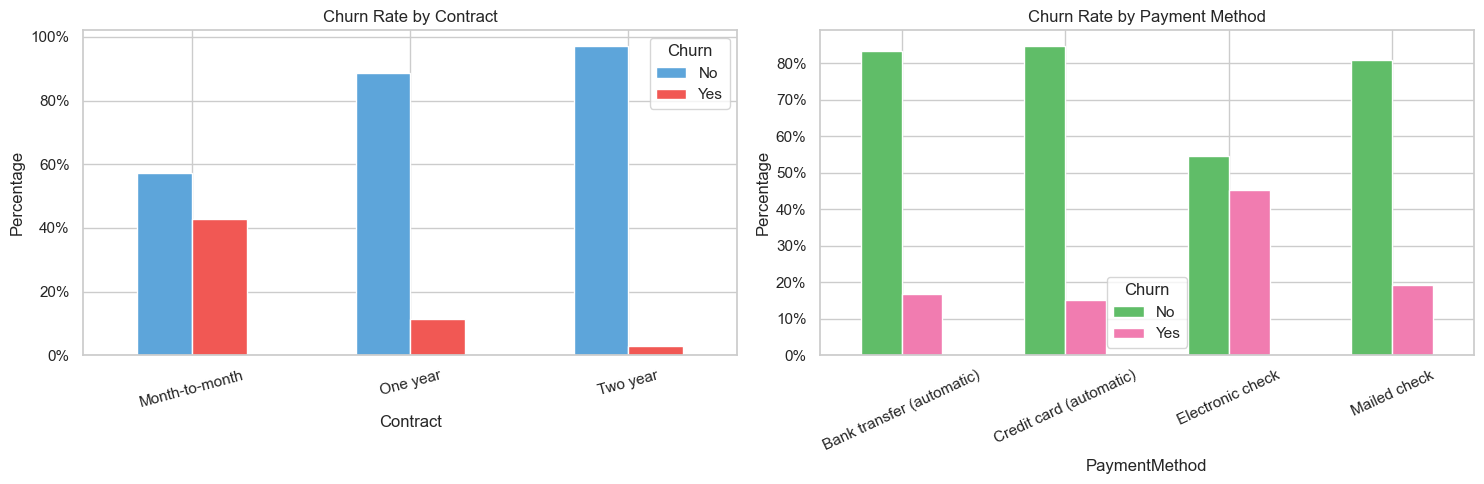

In [14]:
contract_rate = pd.crosstab(df['Contract'], df['Churn'], normalize='index').mul(100)
payment_rate = pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index').mul(100)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

contract_rate.plot(kind='bar', ax=axes[0], color=['#5DA5DA', '#F15854'])
axes[0].set_title('Churn Rate by Contract')
axes[0].set_xlabel('Contract')
axes[0].set_ylabel('Percentage')
axes[0].yaxis.set_major_formatter(PercentFormatter())
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend(title='Churn')

payment_rate.plot(kind='bar', ax=axes[1], color=['#60BD68', '#F17CB0'])
axes[1].set_title('Churn Rate by Payment Method')
axes[1].set_xlabel('PaymentMethod')
axes[1].set_ylabel('Percentage')
axes[1].yaxis.set_major_formatter(PercentFormatter())
axes[1].tick_params(axis='x', rotation=25)
axes[1].legend(title='Churn')

plt.tight_layout()
plt.show()

## 6. Churn theo dịch vụ Internet và các dịch vụ hỗ trợ

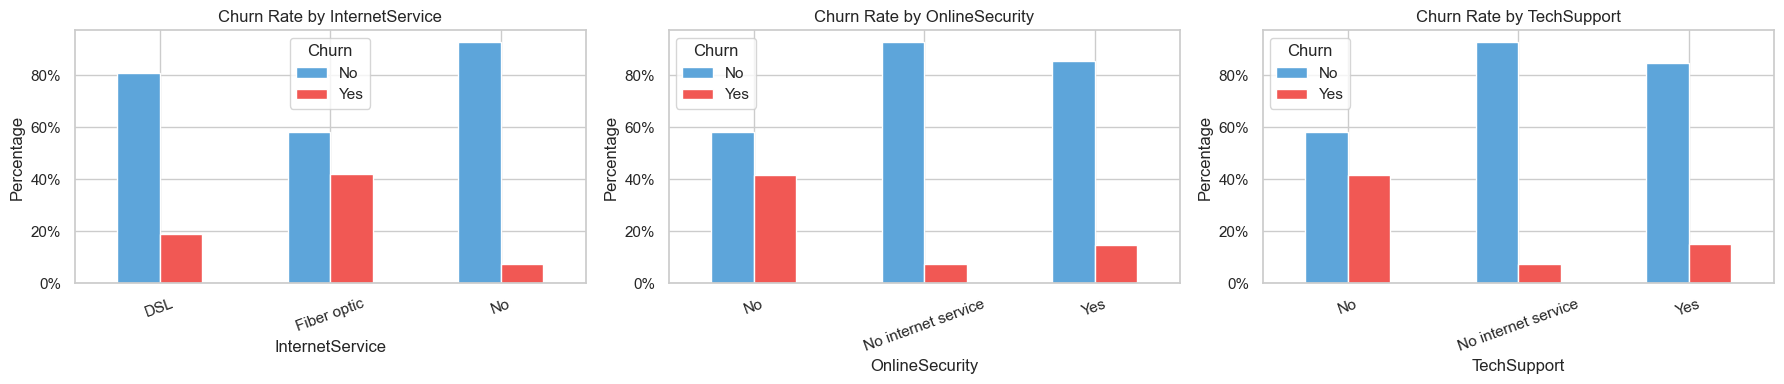

In [15]:
service_columns = ['InternetService', 'OnlineSecurity', 'TechSupport']
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, col in zip(axes, service_columns):
    rate_df = pd.crosstab(df[col], df['Churn'], normalize='index').mul(100)
    rate_df.plot(kind='bar', ax=ax, color=['#5DA5DA', '#F15854'])
    ax.set_title(f'Churn Rate by {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Percentage')
    ax.yaxis.set_major_formatter(PercentFormatter())
    ax.tick_params(axis='x', rotation=20)
    ax.legend(title='Churn')

plt.tight_layout()
plt.show()

## 7. Phân phối các biến số quan trọng

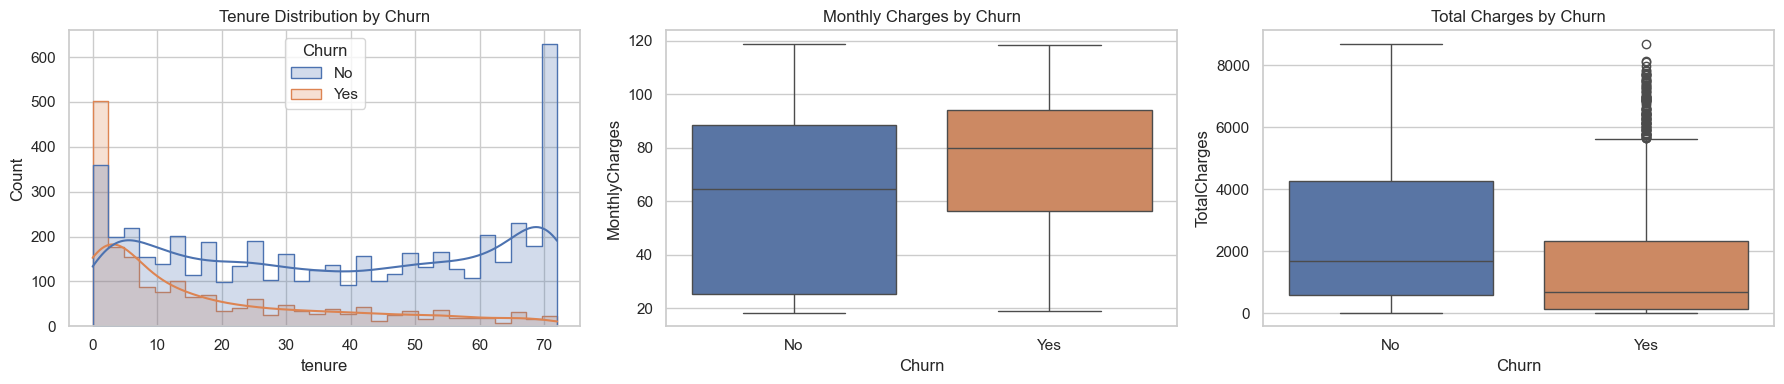

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.histplot(data=df, x='tenure', hue='Churn', bins=30, kde=True, element='step', ax=axes[0])
axes[0].set_title('Tenure Distribution by Churn')

sns.boxplot(data=df, x='Churn', y='MonthlyCharges', hue='Churn', ax=axes[1])
if axes[1].legend_ is not None:
    axes[1].legend_.remove()
axes[1].set_title('Monthly Charges by Churn')

sns.boxplot(data=df, x='Churn', y='TotalCharges', hue='Churn', ax=axes[2])
if axes[2].legend_ is not None:
    axes[2].legend_.remove()
axes[2].set_title('Total Charges by Churn')

plt.tight_layout()
plt.show()

## 8. Churn theo nhóm tenure

Biểu đồ này giúp bạn nói dễ hơn trong phần trình bày: khách mới vào hay khách lâu năm churn nhiều hơn?

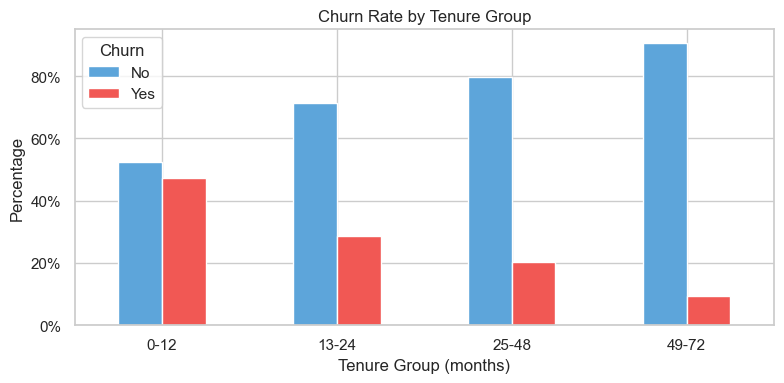

Churn,No,Yes
tenure_group,,
0-12,52.56,47.44
13-24,71.29,28.71
25-48,79.61,20.39
49-72,90.49,9.51


In [17]:
tenure_bins = [0, 12, 24, 48, 72]
tenure_labels = ['0-12', '13-24', '25-48', '49-72']
df_tenure = df.copy()
df_tenure['tenure_group'] = pd.cut(df_tenure['tenure'], bins=tenure_bins, labels=tenure_labels, include_lowest=True)
tenure_group_rate = pd.crosstab(df_tenure['tenure_group'], df_tenure['Churn'], normalize='index').mul(100)

ax = tenure_group_rate.plot(kind='bar', figsize=(8, 4), color=['#5DA5DA', '#F15854'])
ax.set_title('Churn Rate by Tenure Group')
ax.set_xlabel('Tenure Group (months)')
ax.set_ylabel('Percentage')
ax.yaxis.set_major_formatter(PercentFormatter())
ax.legend(title='Churn')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

tenure_group_rate.round(2)

## 9. Tổng hợp nhanh các nhóm có churn cao

In [18]:
important_columns = ['gender', 'Contract', 'PaymentMethod', 'InternetService', 'OnlineSecurity', 'TechSupport']
summary_tables = []

for col in important_columns:
    temp = pd.crosstab(df[col], df['Churn'], normalize='index').mul(100).reset_index()
    temp['feature'] = col
    temp = temp.rename(columns={'Yes': 'churn_rate_%', 'No': 'stay_rate_%', col: 'category'})
    summary_tables.append(temp[['feature', 'category', 'churn_rate_%', 'stay_rate_%']])

insight_df = pd.concat(summary_tables, ignore_index=True).sort_values('churn_rate_%', ascending=False)
insight_df.head(12)

Churn,feature,category,churn_rate_%,stay_rate_%
7,PaymentMethod,Electronic check,45.285412,54.714588
2,Contract,Month-to-month,42.709677,57.290323
10,InternetService,Fiber optic,41.892765,58.107235
12,OnlineSecurity,No,41.766724,58.233276
15,TechSupport,No,41.635474,58.364526
0,gender,Female,26.920872,73.079128
1,gender,Male,26.160338,73.839662
8,PaymentMethod,Mailed check,19.106700,80.893300
9,InternetService,DSL,18.959108,81.040892
5,PaymentMethod,Bank transfer (automatic),16.709845,83.290155


## 10. Kết luận EDA

Các ý bạn có thể chốt trong báo cáo:
- Tỷ lệ churn có tồn tại rõ ràng, nên bài toán dự đoán churn là cần thiết.
- `Month-to-month` là nhóm hợp đồng có churn cao nhất.
- `PaymentMethod`, `TechSupport`, `OnlineSecurity`, `InternetService` có liên quan mạnh đến churn.
- Khách hàng có `tenure` thấp và `MonthlyCharges` cao thường rời bỏ nhiều hơn.
- Đây là cơ sở để chọn các cột quan trọng cho bước train model.